# Invoice Anomaly Detector — Exploratory Data Analysis

Dataset: synthetic invoices with 3 injected anomaly types — `price_spike`,
`quantity_spike`, `tax_error` — generated at a 2% rate, across 10,000
invoices.


## 1. Setup


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import os

print("EDA environment ready..")


EDA environment ready..


In [3]:
from src.database.connection import engine

print("Database connection module loaded.")
print("PostgreSQL engine created.")


Database connection module loaded.
PostgreSQL engine created.


In [4]:
# Test that the notebook can actually communicate with PostgreSQL.
with engine.connect() as connection:
    result = connection.exec_driver_sql("SELECT version();")
    print(result.fetchone()[0])


PostgreSQL 18.4 (Debian 18.4-1.pgdg13+1) on x86_64-pc-linux-gnu, compiled by gcc (Debian 14.2.0-19) 14.2.0, 64-bit


## 2. Load the data

Three tables: `invoices` (one row per invoice), `invoice_items` (one row
per line item), `anomaly_labels` (which invoices were deliberately made
anomalous, and the injected type). These labels only exist because the
data is synthetic — real invoices won't come with a ground-truth label,
which matters later for modeling.


In [5]:
invoices = pd.read_sql(
    """
    SELECT *
    FROM invoices
    ORDER BY invoice_date;
    """,
    engine
)

print(f"Loaded {len(invoices):,} invoices.")
invoices.head()


Loaded 10,000 invoices.


,id,invoice_number,supplier_id,customer_id,invoice_date,currency,subtotal,discount,tax_rate,tax_amount,total,created_at
0,ec4c6edd-ff8f-4c59-84fe-01a336d9cd6a,INV-000766,163585fc-b82b-4c9a-8683-be534139a4d5,30e8ca96-671f-4500-a78c-f53088354927,2025-08-15 12:56:40.401335+00:00,GBP,9429.46,412.00,16.91,1525.25,10542.71,2026-08-15 12:56:38.026990+00:00
1,fe076a88-0b3e-424b-9881-2f8e3d623e42,INV-001085,1b8ce83a-1f7e-4bdc-8970-eff3dd9d2fdc,158a58a1-dd27-402f-ba95-2f9009603fa7,2025-08-15 12:56:41.453902+00:00,GBP,11118.52,0.00,16.37,1819.83,12938.35,2026-08-15 12:56:38.026990+00:00
2,8e7a728b-604c-4066-80f9-95deaa05efa9,INV-001181,762931d2-cc31-41da-bab5-629455e90ec2,9a39990f-a7f2-4d0b-b4d4-fff1a26b32f8,2025-08-15 12:56:41.766372+00:00,GBP,13636.15,0.00,18.62,2539.70,16175.85,2026-08-15 12:56:38.026990+00:00
3,50443f6b-df42-400e-a5cb-7510710b0fb2,INV-001185,209c102c-d80e-458e-994e-14a07a52ae70,6aa155df-f3a7-41a2-a829-6e78d44065a0,2025-08-15 12:56:41.777858+00:00,GBP,8643.62,0.00,16.32,1411.05,10054.67,2026-08-15 12:56:38.026990+00:00
4,7d83eaed-52ee-4a34-83c6-34cee25c987a,INV-001395,67ee40df-99e6-4bc0-93c3-b19d298124e4,ed182225-8708-493b-8296-cb7cf2bace6b,2025-08-15 12:56:42.498241+00:00,GBP,7550.11,377.21,21.00,1506.50,8679.40,2026-08-15 12:56:38.026990+00:00


In [6]:
invoice_items = pd.read_sql(
    """
    SELECT *
    FROM invoice_items;
    """,
    engine,
)

print(f"Loaded {len(invoice_items):,} invoice items.")

# Display the first five items.
invoice_items.head()


Loaded 155,476 invoice items.


,id,invoice_id,product_id,quantity,unit_price,discount,tax_rate,tax_amount,subtotal,total
0,782643bd-ab1e-4115-9fbc-f902410155ef,3fd3f14b-e381-4ae6-a09e-e683d4215822,1b2ecc8f-6f73-4872-a767-205557264136,8.171,64.08,0.0,20.0,104.72,523.60,628.32
1,acffae9d-7c6e-47cd-8dbe-b2a167109fa7,3fd3f14b-e381-4ae6-a09e-e683d4215822,9fee1f8f-324b-4f8d-a96a-3a8c75da8477,40.843,64.40,0.0,5.0,131.51,2630.29,2761.80
2,27b6110b-3c56-4921-b3cc-858bcf90889a,3fd3f14b-e381-4ae6-a09e-e683d4215822,a6902e48-13b0-4897-9e45-f1b8c903aec3,30.000,21.23,0.0,20.0,127.38,636.90,764.28
3,84a354ae-06a8-4830-a750-5963d73155f2,3fd3f14b-e381-4ae6-a09e-e683d4215822,e5b5562d-7ac8-4cdf-b14b-e64bfafe2664,27.982,57.28,0.0,20.0,320.56,1602.81,1923.37
4,2ed02434-8e7b-4523-8e23-0d823272e2c2,3fd3f14b-e381-4ae6-a09e-e683d4215822,a972edd6-87c4-4c14-84ed-571d5636741f,14.019,53.17,0.0,20.0,149.08,745.39,894.47


In [7]:
anomaly_labels = pd.read_sql(
    """
    SELECT *
    FROM anomaly_labels;
    """,
    engine
)

print(f"Loaded {len(anomaly_labels):,} anomaly labels")
anomaly_labels.head()


Loaded 200 anomaly labels


,id,invoice_id,invoice_number,anomaly_type,is_anomaly,created_at
0,740e2f81-24f7-49cf-9f8e-38c2dc412faa,e4c44f5b-2085-40b5-aedc-f7598b988c2c,INV-000010,tax_error,True,2026-08-15 12:56:38.026990+00:00
1,81c5961a-18a0-4565-8ac3-3b6ca138c739,5096de8b-f9cf-4ada-8a22-1b9bc5805be0,INV-000054,quantity_spike,True,2026-08-15 12:56:38.026990+00:00
2,c22839a8-83e1-4006-ab0a-7b3292cb71df,7e0e2a58-3c63-42fe-82eb-01e76d7c34f8,INV-000107,tax_error,True,2026-08-15 12:56:38.026990+00:00
3,14115fd9-98b5-421b-b981-f34e5381a8a3,ecac18c2-c974-4443-9ea9-b3d798a14806,INV-000118,price_spike,True,2026-08-15 12:56:38.026990+00:00
4,08b05749-ea53-405a-9f4c-d607a4b9ad31,cbea57fb-5045-4276-8987-2123774b10f0,INV-000189,tax_error,True,2026-08-15 12:56:38.026990+00:00


In [8]:
print("Invoices:", invoices.shape)
print("Invoice items:", invoice_items.shape)
print("Anomaly labels:", anomaly_labels.shape)


Invoices: (10000, 12)
Invoice items: (155476, 10)
Anomaly labels: (200, 6)


10,000 invoices, 155,476 invoice items (~15-16 items per invoice), 200
anomaly labels — exactly 2% of invoices, matching the generator's
injection rate.


## 3. Data quality check


In [9]:
invoices.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   id              10000 non-null  object             
 1   invoice_number  10000 non-null  str                
 2   supplier_id     10000 non-null  object             
 3   customer_id     10000 non-null  object             
 4   invoice_date    10000 non-null  datetime64[us, UTC]
 5   currency        10000 non-null  str                
 6   subtotal        10000 non-null  float64            
 7   discount        10000 non-null  float64            
 8   tax_rate        10000 non-null  float64            
 9   tax_amount      10000 non-null  float64            
 10  total           10000 non-null  float64            
 11  created_at      10000 non-null  datetime64[us, UTC]
dtypes: datetime64[us, UTC](2), float64(5), object(3), str(2)
memory usage: 937.6+ KB


In [10]:
# Find Missing Values
missing = (
    invoices.isna()
    .sum()
    .sort_values(ascending=False)
)

missing


id                0
invoice_number    0
supplier_id       0
customer_id       0
invoice_date      0
currency          0
subtotal          0
discount          0
tax_rate          0
tax_amount        0
total             0
created_at        0
dtype: int64

In [11]:
# Missing Values in Invoice Items
invoice_items.isna().sum().sort_values(ascending=False)


id            0
invoice_id    0
product_id    0
quantity      0
unit_price    0
discount      0
tax_rate      0
tax_amount    0
subtotal      0
total         0
dtype: int64

No missing values, column types are correct.


## 4. First look at the numbers


In [12]:
# Statistical Summary for Invoice of numerical features
invoices[[
    "subtotal",
    "discount",
    "tax_rate",
    "tax_amount",
    "total"
]].describe()


,subtotal,discount,tax_rate,tax_amount,total
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,9079.385006,108.502181,16.698129,1499.111289,10469.994108
std,5548.176685,284.026196,3.316053,946.154850,6410.598559
min,1.100000,0.000000,0.000000,0.000000,1.320000
25%,4407.360000,0.000000,15.160000,714.710000,5096.877500
50%,8814.055000,0.000000,17.290000,1441.780000,10192.945000
75%,13208.470000,0.000000,19.120000,2184.492500,15213.772500
max,36437.840000,2221.580000,23.820000,5387.750000,38728.620000


In [13]:
anomaly_labels["anomaly_type"].value_counts()


anomaly_type
price_spike       78
tax_error         62
quantity_spike    60
Name: count, dtype: int64

78 `price_spike`, 62 `tax_error`, 60 `quantity_spike` — fairly balanced
across types.


## 5. Build one combined table for analysis

Aggregate `invoice_items` up to invoice level (`groupby("invoice_id")`),
then merge with `invoices` and `anomaly_labels` into one wide table for
comparing normal vs anomalous invoices.


In [14]:
item_features = (
    invoice_items
    .groupby("invoice_id")
    .agg(
        item_count=("id", "count"),
        total_quantity=("quantity", "sum"),
        avg_quantity=("quantity", "mean"),
        max_quantity=("quantity", "max"),
        avg_unit_price=("unit_price", "mean"),
        max_unit_price=("unit_price", "max"),
        avg_tax_rate=("tax_rate", "mean"),
        max_tax_rate=("tax_rate", "max"),
    )
    .reset_index()
)

item_features.head()


,invoice_id,item_count,total_quantity,avg_quantity,max_quantity,avg_unit_price,max_unit_price,avg_tax_rate,max_tax_rate
0,0001583c-b617-40df-9ec1-282a6012bfed,27,478.919,17.737741,43.626,33.976667,76.70,15.740741,20.0
1,0004c0ed-4769-498e-b672-6de8df65adc9,27,531.109,19.670704,48.486,29.576667,67.04,15.185185,20.0
2,000c0d97-1bda-47f2-9c52-25cd9be7d3d7,6,217.425,36.237500,42.872,32.570000,57.05,20.000000,20.0
3,000c83b9-3af2-4c92-88e8-75fb015b068d,10,223.251,22.325100,49.901,32.171000,62.39,18.000000,20.0
4,0013d2e2-2cc2-4a4d-84cd-9fb1665d448c,28,568.756,20.312714,47.129,38.255000,77.47,17.321429,20.0


In [15]:
analysis_df = invoices.merge(
    item_features,
    left_on="id",
    right_on="invoice_id",
    how="left"
)

analysis_df = analysis_df.merge(
    anomaly_labels[["invoice_id", "anomaly_type", "is_anomaly"]],
    on="invoice_id",
    how="left"
)

# Not every invoice has an anomaly_labels row (only the 200 injected
# anomalies do), so after the left-join the rest are NaN. Those NaNs
# genuinely mean "normal" — fillna sets them explicitly instead of
# leaving them as missing data.
analysis_df["is_anomaly"] = (
    analysis_df["is_anomaly"]
    .fillna(False)
    .astype(bool)
)

analysis_df["anomaly_type"] = (
    analysis_df["anomaly_type"]
    .fillna("normal")
)

analysis_df.head()


,id,invoice_number,supplier_id,customer_id,invoice_date,currency,subtotal,discount,tax_rate,tax_amount,...,item_count,total_quantity,avg_quantity,max_quantity,avg_unit_price,max_unit_price,avg_tax_rate,max_tax_rate,anomaly_type,is_anomaly
0,ec4c6edd-ff8f-4c59-84fe-01a336d9cd6a,INV-000766,163585fc-b82b-4c9a-8683-be534139a4d5,30e8ca96-671f-4500-a78c-f53088354927,2025-08-15 12:56:40.401335+00:00,GBP,9429.46,412.00,16.91,1525.25,...,15,286.111,19.074067,47.375,33.283333,60.47,17.666667,20.0,normal,False
1,fe076a88-0b3e-424b-9881-2f8e3d623e42,INV-001085,1b8ce83a-1f7e-4bdc-8970-eff3dd9d2fdc,158a58a1-dd27-402f-ba95-2f9009603fa7,2025-08-15 12:56:41.453902+00:00,GBP,11118.52,0.00,16.37,1819.83,...,18,265.523,14.751278,37.654,35.214444,69.98,16.666667,20.0,price_spike,True
2,8e7a728b-604c-4066-80f9-95deaa05efa9,INV-001181,762931d2-cc31-41da-bab5-629455e90ec2,9a39990f-a7f2-4d0b-b4d4-fff1a26b32f8,2025-08-15 12:56:41.766372+00:00,GBP,13636.15,0.00,18.62,2539.70,...,23,369.661,16.072217,47.046,38.085217,71.02,16.739130,20.0,normal,False
3,50443f6b-df42-400e-a5cb-7510710b0fb2,INV-001185,209c102c-d80e-458e-994e-14a07a52ae70,6aa155df-f3a7-41a2-a829-6e78d44065a0,2025-08-15 12:56:41.777858+00:00,GBP,8643.62,0.00,16.32,1411.05,...,17,286.328,16.842824,49.027,29.558235,68.52,17.647059,20.0,normal,False
4,7d83eaed-52ee-4a34-83c6-34cee25c987a,INV-001395,67ee40df-99e6-4bc0-93c3-b19d298124e4,ed182225-8708-493b-8296-cb7cf2bace6b,2025-08-15 12:56:42.498241+00:00,GBP,7550.11,377.21,21.00,1506.50,...,18,252.457,14.025389,48.980,31.326667,80.46,19.166667,20.0,normal,False


In [16]:
analysis_df[
    [
        "subtotal",
        "tax_rate",
        "item_count",
        "total_quantity",
        "avg_unit_price",
        "max_unit_price",
        "is_anomaly",
        "anomaly_type",
    ]
].head(10)


,subtotal,tax_rate,item_count,total_quantity,avg_unit_price,max_unit_price,is_anomaly,anomaly_type
0,9429.46,16.91,15,286.111,33.283333,60.47,False,normal
1,11118.52,16.37,18,265.523,35.214444,69.98,True,price_spike
2,13636.15,18.62,23,369.661,38.085217,71.02,False,normal
3,8643.62,16.32,17,286.328,29.558235,68.52,False,normal
4,7550.11,21.00,18,252.457,31.326667,80.46,False,normal
5,12562.13,18.64,24,344.141,39.740000,72.29,False,normal
6,14477.14,18.81,22,348.731,41.771818,68.42,False,normal
7,3003.97,11.07,7,63.608,47.690000,67.50,False,normal
8,9855.24,17.51,21,439.490,28.213810,65.44,False,normal
9,2244.40,22.13,3,59.391,34.726667,52.12,False,normal


## 6. Invoice-level: distribution of invoice total


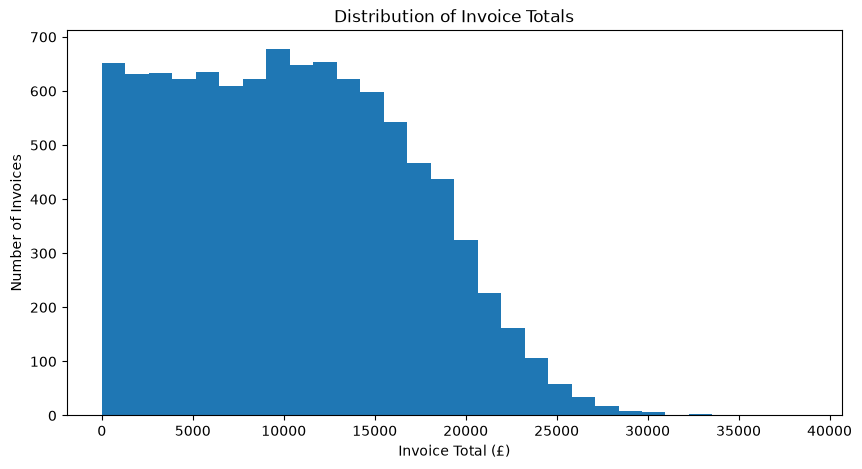

In [17]:
plt.figure(figsize=(10, 5))

plt.hist(invoices["total"], bins=30)

plt.title("Distribution of Invoice Totals")
plt.xlabel("Invoice Total (£)")
plt.ylabel("Number of Invoices")

plt.show()


### Finding: Invoice total distribution

Right-skewed — most invoices sit in the low-to-mid range, with a long tail
toward high-value invoices (up to ~£38,700).

### ML Implication

A high invoice total should not be treated as an automatic anomaly signal.
Legitimate invoices can be high-value too, depending on supplier, customer,
quantity, or product. `total` may still be a useful feature, but not a
standalone rule.


## 7. Do normal and anomalous invoices actually look different?


In [18]:
anomaly_mask = analysis_df["is_anomaly"]

normal_invoices = analysis_df[~anomaly_mask]
anomalous_invoices = analysis_df[anomaly_mask]

print("Normal invoices:", len(normal_invoices))
print("Anomalous invoices:", len(anomalous_invoices))


Normal invoices: 9800
Anomalous invoices: 200


In [19]:
# compare avg invoice total, normal vs anomalous
comparison = pd.DataFrame({
    "Normal": [normal_invoices["total"].mean()],
    "Anomaly": [anomalous_invoices["total"].mean()]
})

comparison


,Normal,Anomaly
0,10440.545672,11912.96745


## Which invoice-level numerical features differ between normal and anomalous invoices?

Comparing `subtotal`, `discount`, `tax_rate`, `tax_amount`, `total` between
groups to see which look worth exploring further.


In [20]:
invoice_features = [
    "subtotal",
    "discount",
    "tax_rate",
    "tax_amount",
    "total",
]

feature_comparison = (
    analysis_df
    .groupby("is_anomaly")[invoice_features]
    .mean()
    .T
)

feature_comparison.columns = ["Normal", "Anomaly"]

feature_comparison


,Normal,Anomaly
subtotal,9053.064054,10369.11165
discount,108.206018,123.01415
tax_rate,16.701646,16.52580
tax_amount,1495.687643,1666.86995
total,10440.545672,11912.96745


### Finding: invoice-level features

Anomaly average total (£11,913) is only ~14% higher than normal (£10,440)
— a modest difference, not a strong separator. `tax_rate` is nearly
identical between groups (16.70 vs 16.53) — note this is the invoice-level
average across all items, not the per-item value examined later.

### ML Implication

Invoice-level totals alone are a weak signal. Item-level detail is likely
more useful than invoice-level aggregates — explored in the rest of this
notebook.


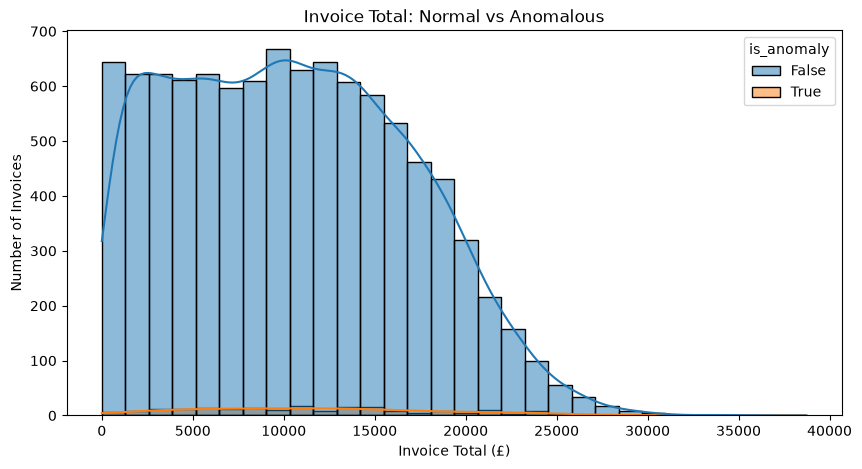

In [21]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=analysis_df,
    x="total",
    hue="is_anomaly",
    bins=30,
    kde=True
)

plt.title("Invoice Total: Normal vs Anomalous")
plt.xlabel("Invoice Total (£)")
plt.ylabel("Number of Invoices")

plt.show()


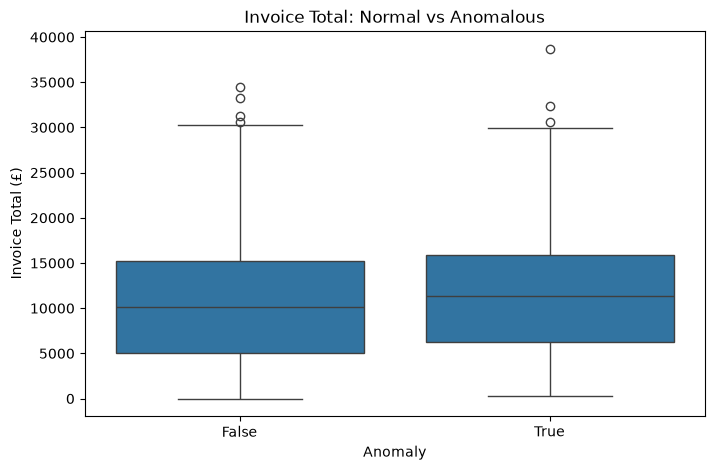

In [22]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=analysis_df,
    x="is_anomaly",
    y="total",
)

plt.title("Invoice Total: Normal vs Anomalous")
plt.xlabel("Anomaly")
plt.ylabel("Invoice Total (£)")

plt.show()


### Finding: invoice total boxplot

Anomalous invoices trend slightly higher, but plenty of normal invoices
also show up as high-value outliers. Confirms a high total alone isn't
enough to call something anomalous.

### ML Implication

The model needs more context than `total` alone — supplier, customer,
product, quantity, unit price, historical behaviour. A value unusual
across the whole dataset might be normal for one specific
supplier-customer relationship.


## How do the three anomaly types compare on invoice total?


In [23]:
anomaly_type_summary = (
    analysis_df[analysis_df["is_anomaly"]]
    .groupby("anomaly_type")["total"]
    .agg(["count", "mean", "min", "max"])
    .round(2)
)

anomaly_type_summary


,count,mean,min,max
anomaly_type,,,,
price_spike,78,11996.92,280.67,25406.42
quantity_spike,60,13456.89,903.94,38728.62
tax_error,62,10313.23,426.99,23918.07


All three anomaly types have overlapping total ranges — type doesn't
produce a clean separation in `total` either. Further evidence to go
deeper, into individual line items.


## 8. Item-level EDA

<!-- ITEM LEVEL EDA -->

Anomalies are injected at the line-item level, not the invoice level, so
an invoice with one spiked item among many normal ones can still have an
unremarkable total. Moving down to `invoice_items`: `quantity`,
`unit_price`, `discount`, `tax_rate`, `tax_amount`, `subtotal`, `total`.


In [24]:
# Load all invoice-item
invoice_items = pd.read_sql(
    """
    SELECT *
    FROM invoice_items
    """,
    engine,
)

print("Invoice items:", invoice_items.shape)
invoice_items.head()


Invoice items: (155476, 10)


,id,invoice_id,product_id,quantity,unit_price,discount,tax_rate,tax_amount,subtotal,total
0,782643bd-ab1e-4115-9fbc-f902410155ef,3fd3f14b-e381-4ae6-a09e-e683d4215822,1b2ecc8f-6f73-4872-a767-205557264136,8.171,64.08,0.0,20.0,104.72,523.60,628.32
1,acffae9d-7c6e-47cd-8dbe-b2a167109fa7,3fd3f14b-e381-4ae6-a09e-e683d4215822,9fee1f8f-324b-4f8d-a96a-3a8c75da8477,40.843,64.40,0.0,5.0,131.51,2630.29,2761.80
2,27b6110b-3c56-4921-b3cc-858bcf90889a,3fd3f14b-e381-4ae6-a09e-e683d4215822,a6902e48-13b0-4897-9e45-f1b8c903aec3,30.000,21.23,0.0,20.0,127.38,636.90,764.28
3,84a354ae-06a8-4830-a750-5963d73155f2,3fd3f14b-e381-4ae6-a09e-e683d4215822,e5b5562d-7ac8-4cdf-b14b-e64bfafe2664,27.982,57.28,0.0,20.0,320.56,1602.81,1923.37
4,2ed02434-8e7b-4523-8e23-0d823272e2c2,3fd3f14b-e381-4ae6-a09e-e683d4215822,a972edd6-87c4-4c14-84ed-571d5636741f,14.019,53.17,0.0,20.0,149.08,745.39,894.47


In [25]:
item_features_raw = [
    "quantity",
    "unit_price",
    "discount",
    "tax_rate",
    "tax_amount",
    "subtotal",
    "total",
]


In [26]:
invoice_items[item_features_raw].describe().T


,count,mean,std,min,25%,50%,75%,max
quantity,155476.0,16.939418,12.097826,1.00,8.00,15.000,23.2205,447.759
unit_price,155476.0,34.365929,20.256510,0.59,16.98,33.660,50.8500,263.300
discount,155476.0,0.000000,0.000000,0.00,0.00,0.000,0.0000,0.000
tax_rate,155476.0,16.506689,7.084622,0.00,20.00,20.000,20.0000,27.000
tax_amount,155476.0,96.420780,114.341402,0.00,14.76,55.600,137.9700,4055.800
subtotal,155476.0,583.973423,596.534655,0.68,152.11,394.465,824.1275,23783.630
total,155476.0,680.394197,696.505948,0.70,176.47,458.140,958.7825,24334.810


Raw item properties may show anomalies more clearly than derived
monetary totals, since `total = quantity × price (+tax)` can dilute a
spike in one factor.


### 8a. Quantity


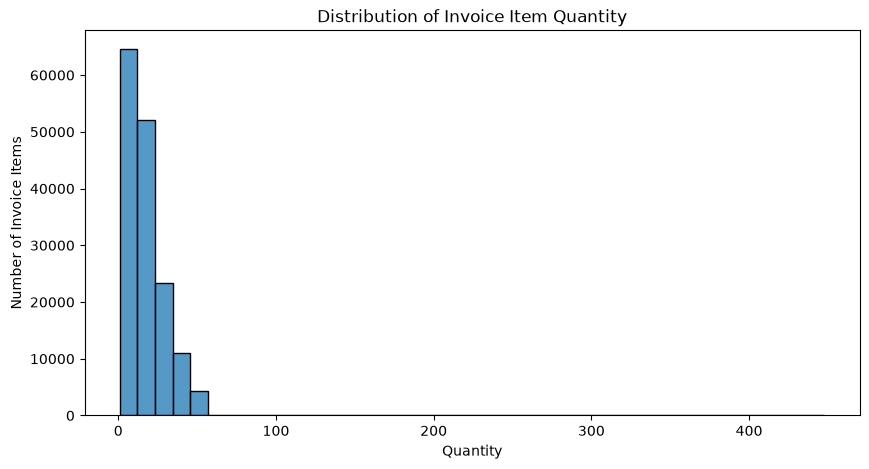

In [27]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=invoice_items,
    x='quantity',
    bins=40
)

plt.title("Distribution of Invoice Item Quantity")
plt.xlabel("Quantity")
plt.ylabel("Number of Invoice Items")

plt.show()


### Finding: item quantity distribution

Heavily right-skewed: most items have quantity between 1-25 (peaking
around 8-15), dropping off sharply after that. Quantities can legitimately
be fractional (e.g. 8.171) — some items are sold by weight/volume, so a
decimal quantity isn't inherently suspicious.

### ML Implication

A long right tail is a plausible signal for `quantity_spike` anomalies,
but needs confirming directly rather than assumed from the plot.


In [28]:
# Find the outlier(s) directly — a stretched x-axis can be caused by a
# handful of extreme rows that don't even show up as a visible bar.
invoice_items.nlargest(10, "quantity")[
    ["id", "invoice_id", "quantity", "unit_price", "total"]
]


,id,invoice_id,quantity,unit_price,total
22517,d7ea4ac5-cd56-49e1-b691-84eedf8ba85a,82a96c4f-d769-4c2c-b516-54b969b03e13,447.759,45.29,24334.81
107269,db5c05ae-3b64-4a52-8003-bf4fc405edee,b8746927-8c8c-4ffc-a729-b59233921613,427.302,55.66,23783.63
95527,e78e3792-c7e1-469f-b757-8453c43b2a72,98b20ea2-a20f-4564-8f02-1bb4eb629062,352.544,31.73,11186.22
61349,7fc73dd7-a80a-422f-9dae-6ec5a4b7c3be,25dad1a5-7c09-42f2-8566-fb6845c7acf1,278.824,47.96,13372.40
35708,295c6c8b-985a-443d-85b5-d2720894bb3e,0a0bbd3f-b3e6-48d1-9d96-eb9334af4180,274.064,10.30,3387.43
39453,fe8fc486-737c-41e2-9232-598e184d84fa,104da5b9-94a2-4b86-8e19-43ad42b5ba5f,255.717,28.33,8693.35
111881,940dba24-f3d5-4c44-bf0b-5819f8069953,89b7a614-e37c-4159-8948-6e07ad340db3,252.000,4.93,1490.83
136050,f9792e72-2bc7-4d8a-acef-51a8ff84217f,fc798cc2-9f4d-46e6-bb1f-a92e8001376c,223.896,21.23,4753.31
143109,0ef0c530-f7ed-4bff-97c8-4237753632d7,eba13a51-3616-4fa2-be68-c491aeb045bc,220.384,50.40,13328.82
761,17afda0a-d0ae-42c8-b645-eafa58d93efc,5096de8b-f9cf-4ada-8a22-1b9bc5805be0,184.752,56.66,12561.66


In [29]:
# Bring the anomaly label onto invoice_items so I can compare
# normal vs anomalous items directly, the same way I did at invoice level.
items_with_labels = invoice_items.merge(
    anomaly_labels[["invoice_id", "anomaly_type", "is_anomaly"]],
    on="invoice_id",
    how="left"
)

items_with_labels["is_anomaly"] = (
    items_with_labels["is_anomaly"].fillna(False).astype(bool)
)

items_with_labels.groupby("is_anomaly")["quantity"].describe()


,count,mean,std,min,25%,50%,75%,max
is_anomaly,,,,,,,,
False,152567.0,16.894667,11.749839,1.0,8.0,15.0,23.1555,50.000
True,2909.0,19.286463,24.003653,1.0,8.0,15.0,24.6410,447.759


### Finding: quantity outliers and class imbalance

Normal items never exceed quantity 50 (max = 50.0 exactly — looks like a
hard cap in the generator). Anomalous items go up to 447.76.

Medians are close (15.0 for both groups), but std and max diverge sharply
(std 11.75 → 24.0, max 50 → 447.76): most anomalous invoices look normal
at the item level — only a small subset carries an extreme spike.

Anomalous items are rare — 2,909 of 155,476 (~1.9%), confirming heavy
class imbalance. Plain accuracy will be a misleading metric later
(predicting "normal" always would already be ~98% "accurate") —
precision/recall or a rare-event approach is needed.


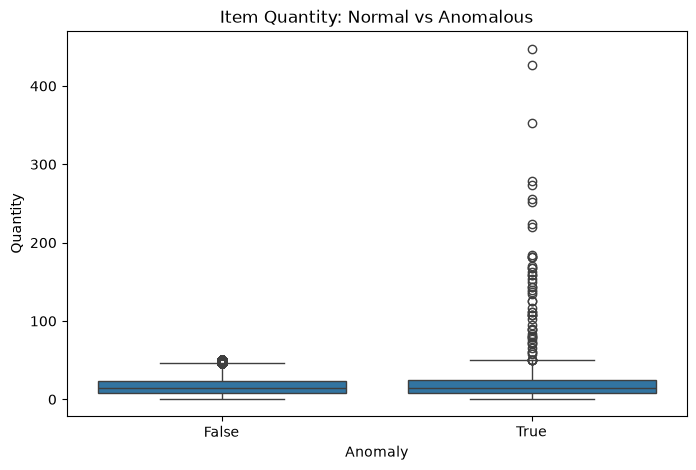

In [30]:
# Box Plot for Quantity
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=items_with_labels,
    x="is_anomaly",
    y="quantity",
)

plt.title("Item Quantity: Normal vs Anomalous")
plt.xlabel("Anomaly")
plt.ylabel("Quantity")

plt.show()


### 8b. Unit price


In [31]:
items_with_labels.groupby("is_anomaly")["unit_price"].describe()


,count,mean,std,min,25%,50%,75%,max
is_anomaly,,,,,,,,
False,152567.0,34.315842,20.139395,0.59,16.96,33.63,50.82,87.14
True,2909.0,36.992839,25.527224,0.70,17.88,35.38,52.70,263.30


### Finding: unit price

Median is close between groups (£33.63 → £35.38), but std and max diverge
sharply (std 20.1 → 25.5, max £87.14 → £263.30) — same "extreme tail, not
a shifted center" pattern as `quantity`.

### ML Implication

`unit_price` median isn't a reliable anomaly signal on its own. This is a
tail/outlier problem — the model should focus on outlier-sensitive methods
(IQR flags, z-scores, isolation-based approaches) rather than comparing
averages or medians between groups.


### 8c. Tax rate


In [32]:
items_with_labels.groupby("is_anomaly")["tax_rate"].describe()


,count,mean,std,min,25%,50%,75%,max
is_anomaly,,,,,,,,
False,152567.0,16.509370,7.083049,0.0,20.0,20.0,20.0,20.0
True,2909.0,16.366105,7.166450,0.0,20.0,20.0,20.0,27.0


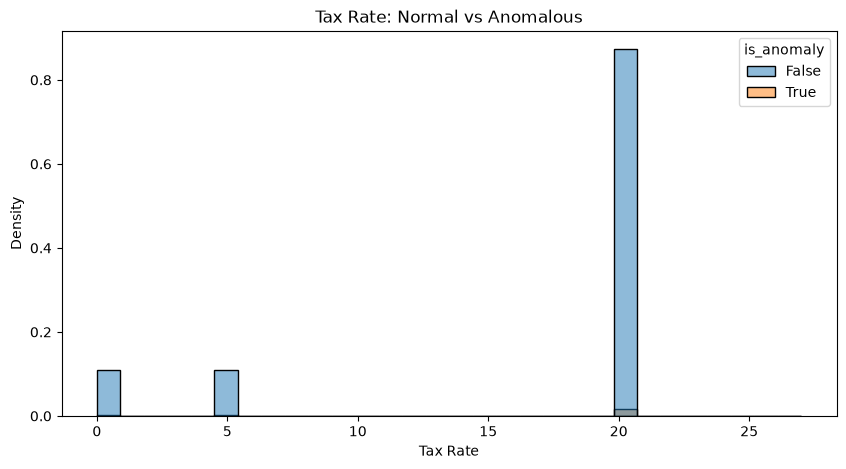

In [33]:
# Histogram instead of boxplot here, since tax_error might show up as a
# separate cluster of values rather than just outliers at the extreme end.
# stat="density" rescales each group so its area sums to 1 — without this,
# the anomaly group (a small fraction of the data) would be nearly
# invisible next to the much larger normal group.
plt.figure(figsize=(10, 5))

sns.histplot(
    data=items_with_labels,
    x="tax_rate",
    hue="is_anomaly",
    bins=30,
    stat="density",
)

plt.title("Tax Rate: Normal vs Anomalous")
plt.xlabel("Tax Rate")
plt.ylabel("Density")

plt.show()


In [34]:
# value_counts on the exact rate values, not just percentiles — this is
# what actually revealed the real story below, since percentiles alone
# were misleading here.
print("Normal items - top tax rates used:")
print(items_with_labels[~items_with_labels["is_anomaly"]]["tax_rate"].value_counts().head(5))

print("\nAnomalous items - top tax rates used:")
print(items_with_labels[items_with_labels["is_anomaly"]]["tax_rate"].value_counts().head(10))


Normal items - top tax rates used:
tax_rate
20.0    122146
0.0      15248
5.0      15173
Name: count, dtype: int64

Anomalous items - top tax rates used:
tax_rate
20.0    2244
5.0      317
0.0      286
17.0      25
13.0      20
27.0      17
Name: count, dtype: int64


In [35]:
# Does an invalid tax rate actually line up with tax_error-labeled
# invoices specifically, or does it show up under other anomaly types too?
# This checks how precise the "invalid rate" signal really is.
invalid_rate_items = items_with_labels[~items_with_labels["tax_rate"].isin([0, 5, 20])]

print("Invalid-rate items by anomaly_type:")
print(invalid_rate_items["anomaly_type"].value_counts(dropna=False))


Invalid-rate items by anomaly_type:
anomaly_type
tax_error    62
Name: count, dtype: int64


### Finding: tax rate — clearest signal so far

Percentiles alone (25th/50th/75th all at 20.0 for both groups) hide the
real structure. Exact value counts show normal items use only three
legitimate rates — 20% (standard), 5% (reduced), 0% (zero-rated) — in
consistent proportions (~81% / 10% / 10%), matching real UK VAT rates.

Anomalous items mostly use these same legitimate rates too (2,847 of
2,909, ~97.9%). A small minority — **62 items (~2.1%)** — use a rate
outside that set: 17%, 13%, or 27%.

### ML Implication

`tax_rate not in {0, 5, 20}` is a precise, low-noise rule — likely a
genuine anomaly when it fires. It's narrow though: it only catches
invoices where an invalid rate was actually used, not every `tax_error`
case (some may show up as a wrong `tax_amount` for an otherwise valid
rate — worth checking during feature engineering). Still the cleanest,
most directly usable rule found so far.


## 9. Summary

| Feature | Finding | Useful signal? |
|---|---|---|
| Invoice `total` | Right-skewed; anomaly vs normal only ~14% apart | Weak alone |
| Item `quantity` | Normal caps at 50; anomalies up to 447.76; medians nearly identical | Tail/outlier signal, not a center shift |
| Item `unit_price` | Median close between groups; std/max diverge sharply | Tail/outlier signal, same pattern as quantity |
| Item `tax_rate` | 3 legitimate rates (0%, 5%, 20%); ~2% of anomalous items use an invalid rate | Strongest, most precise signal — but narrow (low recall) |

This project has labels (`is_anomaly`) because the data is synthetic.
Real invoice data won't come with one, which shapes the modeling plan:

- Use the labels here to build and properly evaluate a **supervised**
  model (precision/recall/F1 against known ground truth).
- Also build an **unsupervised** model (e.g. Isolation Forest) that never
  sees `is_anomaly` during training — the version deployable on real,
  unlabeled invoices.
- Use the synthetic labels purely to score how close the unsupervised
  model gets to the supervised one.